#### Import the required packages with their customary aliases as follows:

    `import pandas as pd`   
    `import numpy as np`  
    `import matplotlib.pyplot as plt`  
    `import seaborn as sns`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Using the pandas `read_csv()` method, read the GDP dataset into your notebook as a DataFrame called `gdp_df`. Take a look at the first few and last few rows to familiarize yourself with what is contained in this dataset.

In [2]:
gdp_df = pd.read_csv('../data/UNdata_gdp.csv')

In [3]:
gdp_df.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN


In [4]:
gdp_df.tail()

,Country or Area,Year,Value,Value Footnotes
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN
8464,Zimbabwe,1990,6082.842451,NaN


#### How many rows and columns are in `gdp_df`? What are the data types of each column?

In [5]:
gdp_df.shape

(8465, 4)

In [6]:
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country or Area  8465 non-null   object 
 1   Year             8465 non-null   int64  
 2   Value            8465 non-null   float64
 3   Value Footnotes  0 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 264.7+ KB


#### Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'GDP_Per_Capita'.

In [7]:
gdp_df = gdp_df.drop(columns = ['Value Footnotes'])

In [8]:
gdp_df.columns = ['Country','Year','GDP_Per_Capita']

#### How many countries have data for all years? Which countries are missing many years of data? Look at the number of observations per year. What do you notice?

In [25]:
year_counts = gdp_df.groupby('Country').size().reset_index()
year_counts.columns = ['Country', 'Count']

all_years = year_counts.loc[year_counts.Count == 35]
all_years

,Country,Count
1,Africa Eastern and Southern,35
2,Africa Western and Central,35
3,Albania,35
4,Algeria,35
5,Andorra,35
...,...,...
240,Vanuatu,35
241,Viet Nam,35
244,World,35
245,Zambia,35


In [26]:
missing_years = year_counts.loc[year_counts.Count < 35]
missing_years.sort_values(by = 'Count')

,Country,Count
55,Djibouti,12
197,Sint Maarten (Dutch part),16
74,Faroe Islands,17
117,Kosovo,17
229,Turks and Caicos Islands,18
38,Cayman Islands,18
242,Virgin Islands (US),21
0,Afghanistan,24
50,CuraÃ§ao,25
190,San Marino,27


In [11]:
gdp_df.Year.value_counts().sort_index()

Year
1990    233
1991    234
1992    234
1993    234
1994    235
1995    236
1996    236
1997    238
1998    238
1999    238
2000    240
2001    240
2002    241
2003    241
2004    241
2005    241
2006    242
2007    243
2008    245
2009    246
2010    246
2011    246
2012    246
2013    247
2014    247
2015    247
2016    247
2017    247
2018    247
2019    247
2020    247
2021    247
2022    247
2023    245
2024    236
Name: count, dtype: int64

#### In this question, you're going to create some plots to show the distribution of GDP per capita for the year 2020. Go to the Python Graph Gallery (https://www.python-graph-gallery.com/) and look at the different types of plots under the Distribution section. Create a histogram, a density plot, a boxplot, and a violin plot. What do you notice when you look at these plots? How do the plots compare and what information can you get out of one type that you can't necessarily get out of the others?

<Axes: xlabel='GDP_Per_Capita', ylabel='Count'>

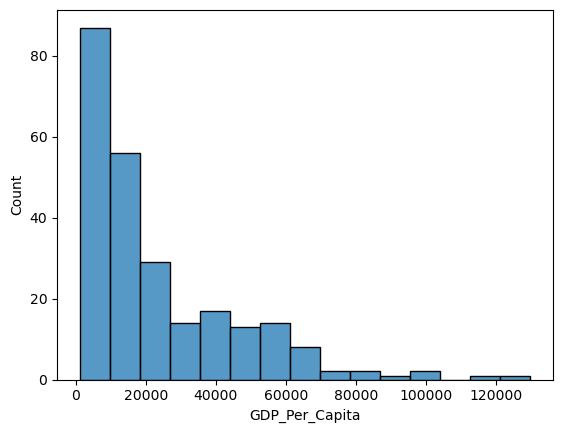

In [12]:
data_2020 = gdp_df.loc[gdp_df['Year'] == 2020]
sns.histplot(data=data_2020, x="GDP_Per_Capita",bins=15)

<Axes: xlabel='GDP_Per_Capita', ylabel='Density'>

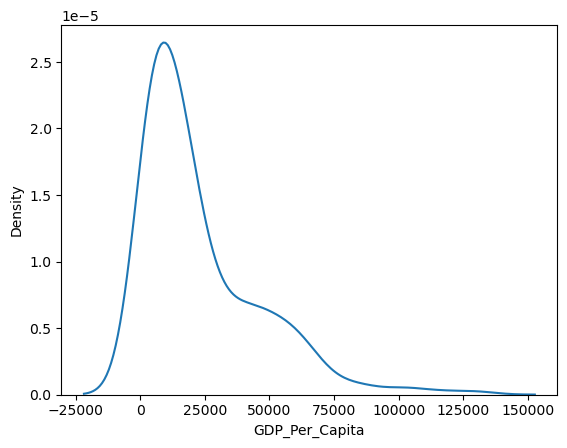

In [13]:
sns.kdeplot(data_2020['GDP_Per_Capita'])

<Axes: ylabel='GDP_Per_Capita'>

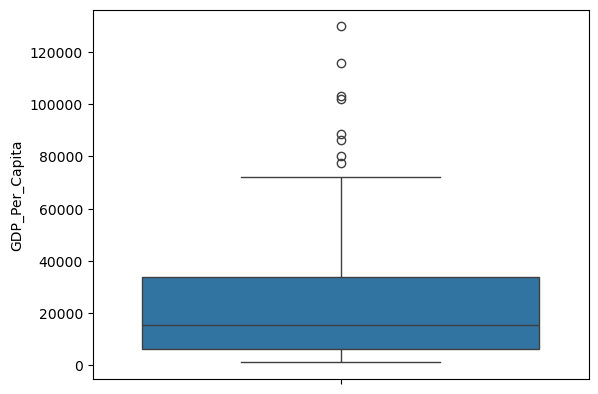

In [14]:
sns.boxplot(y=data_2020["GDP_Per_Capita"])

<Axes: ylabel='GDP_Per_Capita'>

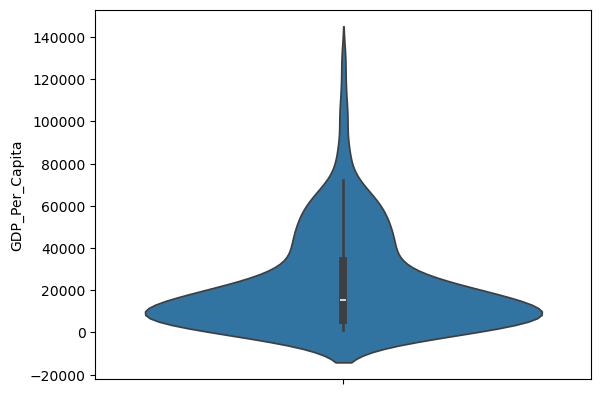

In [15]:
sns.violinplot(y=data_2020["GDP_Per_Capita"])

**Answer:** The histogram and density plots provide a great way to see the distribution of the data. The box plot provides a way to see the overall statistics, especially the outliers. The violin plot does this similarly, but it shows the density more like a classic density plot.

#### What was the median GDP per capita value in 2020?

In [16]:
data_2020["GDP_Per_Capita"].median()

15399.308958012449

#### For this question, you're going to create some visualizations to compare GDP per capita values for the years 1990, 2000, 2010, and 2020. Start by subsetting your data to just these 4 years into a new DataFrame named gdp_decades. Using this, create the following 4 plots:
- A boxplot
- A barplot (check out the Barplot with Seaborn section: https://www.python-graph-gallery.com/barplot/#Seaborn)
- A scatterplot
- A scatterplot with a trend line overlaid (see this regplot example: https://www.python-graph-gallery.com/42-custom-linear-regression-fit-seaborn)  

**Comment on what you observe has happened to GDP values over time and the relative strengths and weaknesses of each type of plot.**

In [17]:
gdp_decades = gdp_df.loc[(gdp_df['Year'] == 1990) | (gdp_df['Year'] == 2000) | (gdp_df['Year'] == 2010) | (gdp_df['Year'] == 2020)]
gdp_decades

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
13,Afghanistan,2010,2848.586061
23,Afghanistan,2000,1617.826475
28,Africa Eastern and Southern,2020,3978.931395
38,Africa Eastern and Southern,2010,3976.010989
...,...,...,...
8429,Zambia,1990,2425.111287
8434,Zimbabwe,2020,4527.719881
8444,Zimbabwe,2010,3885.393785
8454,Zimbabwe,2000,6170.333908


<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

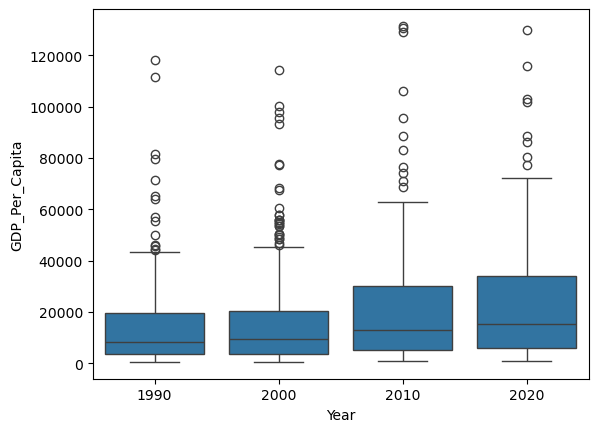

In [18]:
sns.boxplot(x=gdp_decades["Year"], y=gdp_decades["GDP_Per_Capita"])

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

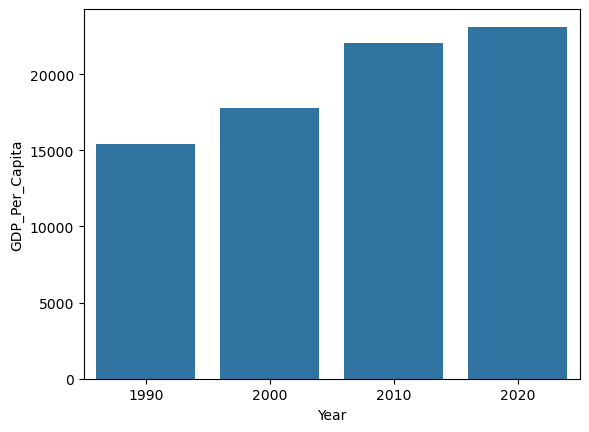

In [19]:
sns.barplot(
    y="GDP_Per_Capita",
    x="Year",
    data=gdp_decades,
    errorbar=None)

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

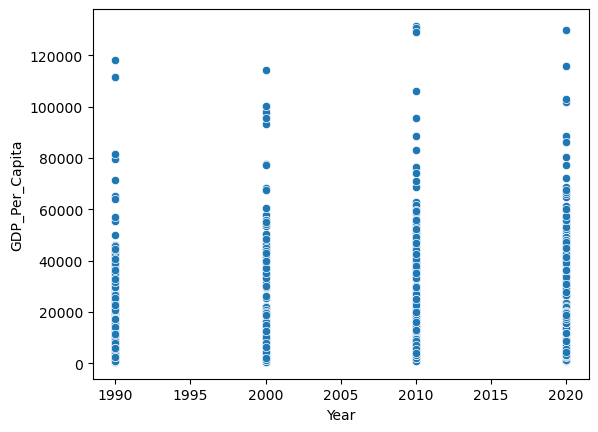

In [20]:
sns.scatterplot(
    data=gdp_decades,
    x="Year",
    y="GDP_Per_Capita"
)

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

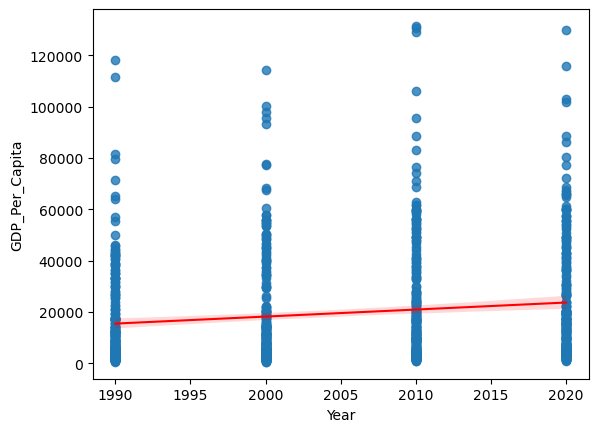

In [21]:
sns.regplot(
    x=gdp_decades["Year"],
    y=gdp_decades["GDP_Per_Capita"],
    line_kws={"color":"red", "linewidth": 1.5})

**Answer:** Overall GDP values seem to be trending upward over the years. The boxplot demonstrates best how the distribution of GDP values change, but for years with a wider distribution (like 2020), the outliers of the overall statistics get lost in the visualization. The barplot provides an excellent representation for the change in the total GDP per Capita over the year, but doesn't really show the distribution of these values across each country. The scatter plot does this effectively, but since the year is a discrete column, the values are plotted with lots of overlap in vertical lines. The added trend line shows how the data's distribution has changed, but the data points are still lost in the scatter plot when the GDP values are closer together.

#### Which country was the first to have a GDP per capita greater than $100,000?

In [27]:
country_list = gdp_df.sort_values(by=['Year','GDP_Per_Capita'])
country_list = country_list.loc[country_list.GDP_Per_Capita > 100000]
country_list

,Country,Year,GDP_Per_Capita
8062,United Arab Emirates,1990,111377.046890
1037,Brunei Darussalam,1990,118163.683370
8061,United Arab Emirates,1991,106266.193694
1036,Brunei Darussalam,1991,118220.683595
8060,United Arab Emirates,1992,104206.754891
...,...,...,...
6367,Qatar,2024,110889.792702
4660,"Macao SAR, China",2024,111693.502831
3664,Ireland,2024,119037.731175
4625,Luxembourg,2024,128475.279803


**Answer:** United Arab Emirates & Brunei Darussalem

#### Which country had the highest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

In [31]:
data_2020.sort_values(by = 'GDP_Per_Capita', ascending = False)

,Country,Year,GDP_Per_Capita
4629,Luxembourg,2020,129865.629988
6778,Singapore,2020,115893.042396
6371,Qatar,2020,103061.899445
3668,Ireland,2020,101968.554362
798,Bermuda,2020,88618.083068
...,...,...,...
5357,Mozambique,2020,1466.124765
6969,"Somalia, Fed. Rep.",2020,1396.055447
1620,"Congo, Democratic Republic of",2020,1361.027911
1375,Central African Republic,2020,1136.570530


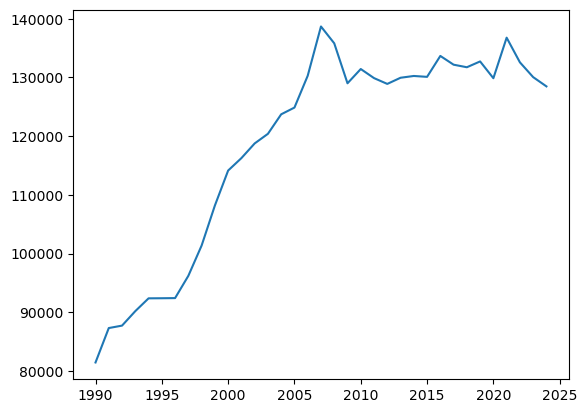

In [71]:
luxembourg_data = gdp_df.loc[gdp_df['Country'] == 'Luxembourg']
plt.plot('Year','GDP_Per_Capita',data=luxembourg_data)

#### Which country had the lowest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset. 
**Bonus question:** Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?

In [41]:
data_2020.sort_values(by = 'GDP_Per_Capita')

,Country,Year,GDP_Per_Capita
1112,Burundi,2020,1030.770264
1375,Central African Republic,2020,1136.570530
1620,"Congo, Democratic Republic of",2020,1361.027911
6969,"Somalia, Fed. Rep.",2020,1396.055447
5357,Mozambique,2020,1466.124765
...,...,...,...
798,Bermuda,2020,88618.083068
3668,Ireland,2020,101968.554362
6371,Qatar,2020,103061.899445
6778,Singapore,2020,115893.042396


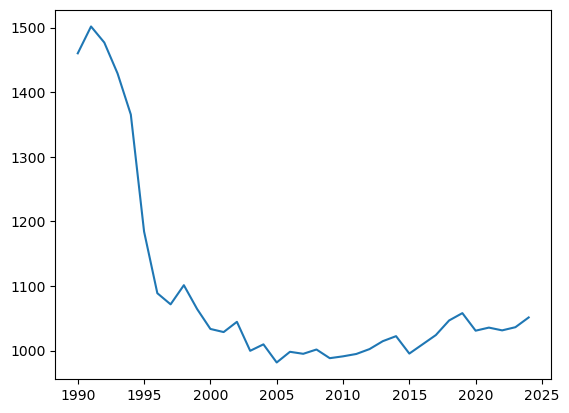

In [70]:
burundi_data = gdp_df.loc[gdp_df['Country'] == 'Burundi']
plt.plot('Year','GDP_Per_Capita',data=burundi_data)

#### Read in the internet use dataset into a DataFrame named `internet_df`. You will likely get errors when doing this. Check the arguments for the read_csv function to find ones that can help correct the errors (https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) Once you are able to read it in, take per a look at the top and bottom few rows to make sure that it has been read in correctly. Also, check the datatypes of the columns.

In [66]:
internet_df = pd.read_csv(
    '../data/UNdata_internet_usage.csv', 
    nrows=6083)

#### Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'Internet_Users_Pct'.

In [67]:
internet_df = internet_df.drop(columns = ['Value Footnotes'])
internet_df.columns = ['Country', 'Year', 'Internet_Users_Pct']

#### Look at the number of observations in this dataset per year. What do you notice?

In [68]:
obs_counts = gdp_df.groupby('Year').size().reset_index()
obs_counts.columns = ['Year', 'Count']
obs_counts

,Year,Count
0,1990,233
1,1991,234
2,1992,234
3,1993,234
4,1994,235
5,1995,236
6,1996,236
7,1997,238
8,1998,238
9,1999,238


**Answer:** Number of observations per year slowly increased until they peaked from 2013-2022 then starting to decline

#### What is the first year to have a non-zero internet users percentage value?

In [65]:
non_zero_years = internet_df.loc[internet_df.Internet_Users_Pct > 0]
non_zero_years.sort_values(by = 'Year')

,Country,Year,Internet_Users_Pct
1570,Denmark,1990,0.097277
2892,Japan,1990,0.020294
306,Australia,1990,0.585095
2034,France,1990,0.052778
339,Austria,1990,0.130369
...,...,...,...
427,Bangladesh,2023,44.502700
677,Bosnia and Herzegovina,2023,83.377200
1656,Ecuador,2023,72.694300
1537,Denmark,2023,98.775600


**Answer:** 1990 

#### How does the distribution of internet users percent differ for 2000 and 2014?

In [75]:
internetdata_2000 = internet_df.loc[internet_df['Year'] == 2000]
internetdata_2014 = internet_df.loc[internet_df['Year'] == 2014]

<Axes: xlabel='Internet_Users_Pct', ylabel='Count'>

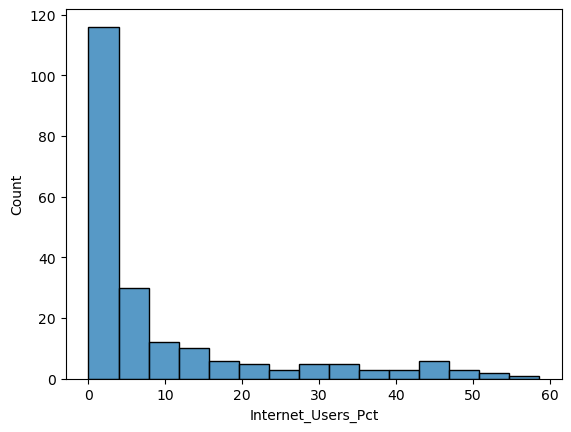

In [76]:
sns.histplot(data=internetdata_2000, x='Internet_Users_Pct', bins = 15)

<Axes: xlabel='Internet_Users_Pct', ylabel='Count'>

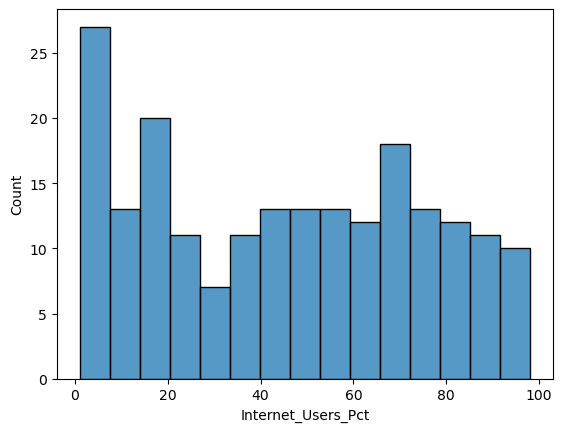

In [77]:
sns.histplot(data=internetdata_2014, x='Internet_Users_Pct', bins = 15)

**Answer:** The overall percentage of internet users was very low in 2000, but the distribution shifted in 2014 as more countries reported higher internet usage. There are still many countries that report very low usage, but the overall majority obviously shifted towards more internet usage.

#### For how many countries was the percentage of internet users below 5% in 2014?

In [84]:
below_5 = internet_df.loc[(internet_df['Year'] == 2014) & (internet_df['Internet_Users_Pct'] < 5)]
below_5.count()

Country               10
Year                  10
Internet_Users_Pct    10
dtype: int64

#### Merge the two DataFrames to one. Do this in a way that keeps **all rows** from each of the two DataFrames. Call the new DataFrame `gdp_and_internet_use`. Look at the first and last few rows to confirm that it merged correctly.

In [87]:
gdp_and_internet_use = pd.merge(gdp_df, internet_df, on=['Country', 'Year'])

In [89]:
gdp_and_internet_use.head()

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
0,Afghanistan,2019,2927.245144,17.60
1,Afghanistan,2018,2902.392113,16.80
2,Afghanistan,2017,2952.998916,13.50
3,Afghanistan,2016,2958.785399,11.00
4,Afghanistan,2015,2967.692067,8.26


In [90]:
gdp_and_internet_use.tail()

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
4763,Zimbabwe,1997,6524.062658,0.033080
4764,Zimbabwe,1996,6474.160183,0.016790
4765,Zimbabwe,1995,5964.589380,0.007684
4766,Zimbabwe,1994,6010.742417,0.001739
4767,Zimbabwe,1990,6082.842451,0.000000


#### Find the three countries with the highest internet users percentage in 2014. Use a seaborn FacetGrid (https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) to compare how the GDP per capita has changed over time for these three countries. What do you notice?

#### Subset `gdp_and_internet_use` to just the year 2014. Save this as a new dataframe named `gdp_and_internet_use_2014`.

#### Create a plot which compares Internet Users Percentage and GDP per Capita for the year 2014. What do you notice from this plot? If you see any unusual points, investigate them.

#### **Stretch Question:** Use the `qcut` function from pandas (https://pandas.pydata.org/docs/reference/api/pandas.qcut.html) to divide countries in `gdp_per_capita_2014` into three groups based on their GDP per capita values. Label these groups as "Low", "Medium", and "High". Put these labels in a new column, named "GDP_group".

#### **Stretch Question:** How does the median internet users percentage compare for the three gdp groups?

#### Bonus exercise:
1.    Download another data set from the UN data (http://data.un.org/Explorer.aspx) to merge with your data and explore.